In [1]:
import pandas as pd

from lib.h_ensemble import build_ensemble_csv
from lib.uncertainty import compute_uncertainties
import numpy as np
# load data 
""" MAIN SETTINGS AND DATA LOADING"""


dataset = 'ms_neuro'
analysis_name = 'ms_progression'
outcome_name = 'progression_independent_from_relapses'
build_ensemble_csv(analysis_name, outcome_name)


all_patients = pd.read_csv(f'../data/{dataset}/X.csv')
all_patients_y = pd.read_csv(f'../data/{dataset}/y.csv')

all_patients['label'] = all_patients_y[outcome_name].astype(int)


# load all predictions for the full training set (including active patients at bl)
patients_stats = pd.read_csv(f'../results/classification/{analysis_name}/{outcome_name}/aggregated/patient_mean_probs_{outcome_name}_{analysis_name}_model.csv')
patients_stats.index = patients_stats['idx']



# 1. Extract the inner list from each row using .str[0]
import ast

# 1. Convert the string representation "[0.8, 0.83...]" into a real Python list
real_lists = patients_stats['all_probs'].apply(ast.literal_eval)

# 2. Now expand those lists into columns
probs_raw_df = pd.DataFrame(real_lists.tolist(), index=patients_stats['idx'].values)

actual_outcomes = patients_stats['label'].values
mean_probs = patients_stats['mu'].values

best_tau = 0.11

Skipping stacking as it's not in the list of models to include.
Skipping voting as it's not in the list of models to include.
Successfully aggregated 21600 predictions across 719 unique patients.


In [2]:
# Compute uncertainties for the non-active patients at baseline
from scipy.stats import pointbiserialr

tau = best_tau  # This is the threshold we want to test
uncertainty_metrics, tau = compute_uncertainties(probs_raw_df, patients_stats, tau=tau)
predictions = (patients_stats['mu'] >= tau).astype(int)

# Compute error indicator
is_error = (predictions != actual_outcomes).astype(int)

# Test each metric
results = []

for name, metric in uncertainty_metrics.items():
    # For metrics where LOW = uncertain, flip the sign
    if name in ['Margin', 'Distance_to_tau']:
        metric_for_corr = -metric  # Higher values = more uncertain
    else:
        metric_for_corr = metric
    
    # Compute correlation
    r, p_value = pointbiserialr(is_error, metric_for_corr)
    
    results.append({
        'Metric': name,
        'Correlation': r,
        'P-value': p_value,
        'Significant': p_value < 0.05
    })
    
    print(f"{name:25s} | r = {r:6.3f} | p = {p_value:.4f} | {'✓' if p_value < 0.05 else '✗'}")

# Sort by absolute correlation
results_df = pd.DataFrame(results)
results_df['Abs_Correlation'] = results_df['Correlation'].abs()
results_df = results_df.sort_values('Abs_Correlation', ascending=False)

print("\n=== RANKED BY PREDICTIVE POWER ===")
print(results_df.to_string(index=False))



H_total                   | r =  0.610 | p = 0.0000 | ✓
Margin                    | r = -0.292 | p = 0.0000 | ✓
Inverse_Margin            | r = -0.074 | p = 0.0469 | ✓
Ensemble_Variance         | r =  0.382 | p = 0.0000 | ✓
Ensemble_Std              | r =  0.456 | p = 0.0000 | ✓
H_tau_symmetric           | r =  0.487 | p = 0.0000 | ✓
H_tau_imbalanced          | r =  0.500 | p = 0.0000 | ✓
Var_over_margin           | r =  0.405 | p = 0.0000 | ✓
Distance_to_tau           | r = -0.292 | p = 0.0000 | ✓

=== RANKED BY PREDICTIVE POWER ===
           Metric  Correlation      P-value  Significant  Abs_Correlation
          H_total     0.610190 1.491783e-74         True         0.610190
 H_tau_imbalanced     0.500093 9.192599e-47         True         0.500093
  H_tau_symmetric     0.486595 5.199070e-44         True         0.486595
     Ensemble_Std     0.456389 2.807050e-38         True         0.456389
  Var_over_margin     0.405425 8.038697e-30         True         0.405425
Ensemble_Varianc

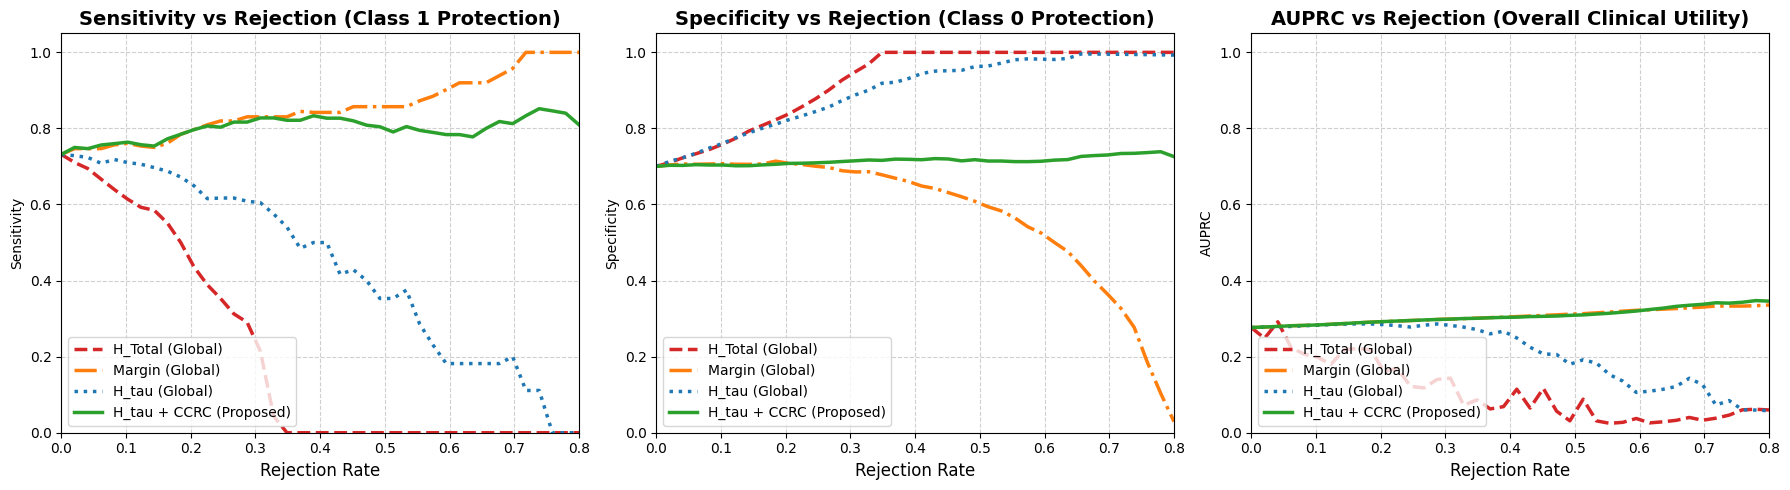

In [3]:
from lib.uncertainty import compute_ablation_metrics
import matplotlib.pyplot as plt

# ==========================================
# EXECUTE THE 4-WAY ABLATION STUDY
# ==========================================
# (Assuming actual_outcomes, mean_probs, best_tau, and your metrics dictionary are already loaded)

# Sweep from 0% to 80% rejection to capture the crashes
reject_rates = np.linspace(0, 0.80, 40) 

# Ensure metrics are oriented so HIGH = Uncertain
h_total_scores = uncertainty_metrics['H_total']
h_tau_scores = uncertainty_metrics['H_tau_symmetric']
margin_scores = -np.abs(mean_probs - best_tau) # Pure Margin inverted: small distance -> high uncertainty

# 1. Standard AI (H_Total Global)
df_htotal_global = compute_ablation_metrics(
    actual_outcomes, mean_probs, best_tau, h_total_scores, reject_rates, mode='global'
)

# 2. Pure Margin Global (The Naive Fix)
df_margin_global = compute_ablation_metrics(
    actual_outcomes, mean_probs, best_tau, margin_scores, reject_rates, mode='global'
)

# 3. Piecewise Entropy Global (The Theoretical Fix)
df_htau_global = compute_ablation_metrics(
    actual_outcomes, mean_probs, best_tau, h_tau_scores, reject_rates, mode='global'
)

# 4. Piecewise Entropy + CCRC (The SOTA Pipeline)
df_htau_ccrc = compute_ablation_metrics(
    actual_outcomes, mean_probs, best_tau, h_tau_scores, reject_rates, mode='ccrc'
)

# ==========================================
# VISUALIZE THE RESULTS
# ==========================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

configs = [
    ('H_Total (Global)', df_htotal_global, '#d62728', '--'),   # Red, dashed (Standard AI Failure)
    ('Margin (Global)', df_margin_global, '#ff7f0e', '-.'),    # Orange, dash-dot (Runway Failure)
    ('H_tau (Global)', df_htau_global, '#1f77b4', ':'),        # Blue, dotted (Density Failure)
    ('H_tau + CCRC (Proposed)', df_htau_ccrc, '#2ca02c', '-')  # Green, solid (The Fix)
]

for name, df, color, linestyle in configs:
    axes[0].plot(df['Reject_Rate'], df['Sensitivity'], label=name, color=color, linestyle=linestyle, linewidth=2.5)
    axes[1].plot(df['Reject_Rate'], df['Specificity'], label=name, color=color, linestyle=linestyle, linewidth=2.5)
    axes[2].plot(df['Reject_Rate'], df['AUPRC'], label=name, color=color, linestyle=linestyle, linewidth=2.5)

# Formatting Panel 1: Sensitivity (Tracks Minority-Class Erasure)
axes[0].set_title("Sensitivity vs Rejection (Class 1 Protection)", fontsize=14, fontweight='bold')
axes[0].set_ylabel("Sensitivity")

# Formatting Panel 2: Specificity (Tracks Majority-Class Erasure)
axes[1].set_title("Specificity vs Rejection (Class 0 Protection)", fontsize=14, fontweight='bold')
axes[1].set_ylabel("Specificity")

# Formatting Panel 3: AUPRC (Overall Clinical Trajectory)
axes[2].set_title("AUPRC vs Rejection (Overall Clinical Utility)", fontsize=14, fontweight='bold')
axes[2].set_ylabel("AUPRC")

# Universal Formatting
for ax in axes:
    ax.set_xlabel("Rejection Rate", fontsize=12)
    ax.set_xlim([0, 0.80])
    ax.set_ylim([0, 1.05])
    ax.legend(fontsize=10, loc='lower left')
    ax.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

Here is the exact mathematical reason why CCRC + $H_{Total}$ fails, why CCRC + Margin is redundant, and how this makes your theoretical argument even stronger.

1. Why CCRC + $H_{Total}$ is Mathematically DisastrousIf you apply CCRC to standard $H_{Total}$, the algorithm will actually perform worse than global rejection. 

    Here is why: To sort patients safely within a class, the uncertainty metric must be strictly monotonic (it must constantly decrease as you move away from the boundary $\tau$).For your MS dataset ($\tau = 0.11$), look at Class 1 (the Progressors). The interval is $[0.11, 1.0]$.
    
    Standard $H_{Total}$ peaks at 0.5. If a patient has $p = 0.12$ (Borderline), their $H_{Total}$ is roughly 0.53.If a patient has $p = 0.50$ (Confident Progressor), their $H_{Total}$ is 1.0.If you use CCRC to say "Discard the patients in Class 1 with the highest $H_{Total}$," the algorithm will look at those two patients and discard the confident 0.50 patient and keep the borderline 0.12 patient! Because $H_{Total}$ is non-monotonic on the right side of $\tau$, CCRC actually inverts the sorting logic, acting as an intentional Minority-Class Eraser. This proves that CCRC cannot save a broken metric. You must fix the metric's peak ($H_\tau$) before CCRC can correctly sort the patients.

2. Why CCRC + Margin is RedundantAs we discussed previously, CCRC only cares about the rank order (ordinality) of the patients within their class.Because $H_\tau$ is just a mathematical stretching of the absolute Margin, sorting Class 1 by Margin drops the exact same patients as sorting Class 1 by $H_\tau$.If you plotted CCRC + Margin on your graphs, it would be a line perfectly, 100% stacked underneath the Green line (CCRC + H_\tau). It wouldn't add any new visual information.

## AUGRC Results using Htau + CCRC and Global rejection
Now that we understand the mathematical issues, let's look at the actual AUGRC results when we apply CCRC to both the global risk and the class-specific risks.

In [4]:
# 4. Piecewise Entropy + CCRC (The SOTA Pipeline)
from lib.uncertainty import compute_ablation_metrics2


df_htau_ccrc = compute_ablation_metrics2(
    actual_outcomes, mean_probs, best_tau, h_tau_scores, reject_rates, mode='ccrc'
)

# 1. Standard AI (H_Total Global)
df_htotal_global = compute_ablation_metrics2(
    actual_outcomes, mean_probs, best_tau, h_total_scores, reject_rates, mode='global'
)


In [7]:
from sklearn.metrics import auc

# Sort by Coverage ascending so auc() integrates correctly
df_sorted = df_htau_ccrc.sort_values(by='Coverage')

coverage = df_sorted['Coverage'].values
global_risk = df_sorted['Global_Gen_Risk'].values
cc_risk_1 = df_sorted['ccGen_Risk_1'].values
cc_risk_0 = df_sorted['ccGen_Risk_0'].values
# Calculate Areas
global_augrc = auc(coverage, global_risk)
class1_augrc = auc(coverage, cc_risk_1)
class0_augrc = auc(coverage, cc_risk_0)

print(f"Global AUGRC (htau_ccrc): {global_augrc:.4f}")
print(f"Progressor AUGRC (htotal_ccrc): {class1_augrc:.4f}")
print(f"Non progressor AUGRC (htau_ccrc): {class0_augrc:.4f}")

Global AUGRC (htau_ccrc): 0.1336
Progressor AUGRC (htotal_ccrc): 0.1041
Non progressor AUGRC (htau_ccrc): 0.1374


In [8]:
from sklearn.metrics import auc

# Sort by Coverage ascending so auc() integrates correctly
df_sorted = df_htotal_global.sort_values(by='Coverage')

coverage = df_sorted['Coverage'].values
global_risk = df_sorted['Global_Gen_Risk'].values
cc_risk_1 = df_sorted['ccGen_Risk_1'].values
cc_risk_0 = df_sorted['ccGen_Risk_0'].values

# Calculate Areas
global_augrc = auc(coverage, global_risk)
class1_augrc = auc(coverage, cc_risk_1)
class0_augrc = auc(coverage, cc_risk_0)

print(f"Global AUGRC (htotal_global): {global_augrc:.4f}")
print(f"Progressor AUGRC (htotal_global): {class1_augrc:.4f}")
print(f"Non progressor AUGRC (htau_global): {class0_augrc:.4f}")

Global AUGRC (htotal_global): 0.0665
Progressor AUGRC (htotal_global): 0.1581
Non progressor AUGRC (htau_global): 0.0547
